## Imports

In [2]:
import dill 
import random
from math import sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import shap
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from pipe.src.feature_enjineering.feature_selector import FeatureSelector
from pipe.src.modeling.validator import TimeSeriesValidator

In [3]:
x_full = pd.read_csv("../pipe/data/processed/x_full.csv")
x_full.head()

,lag_1_month,lag_2_month,lag_3_month,avg_item_cnt_prev_month,avg_shop_cnt_prev_month,month,year,item_age,shop_age,category_age,...,group_cnt_lag1,group_cnt_all_shops_lag1,item_name_first4,item_name_first6,item_name_first11,group_id,group_age,category_cnt_median_lag1,category_cnt_all_shops_median_lag1,city_cnt_lag1
0,1,4,0,3,1,4,2013,2,3,3,...,1,1,2,2,3,10,3,1,1,1
1,0,0,0,1,1,4,2013,3,3,3,...,2,1,34,39,55,11,3,1,1,1
2,1,1,1,1,1,4,2013,3,3,3,...,1,2,35,43,59,14,3,1,1,1
3,2,4,2,5,1,4,2013,3,3,3,...,1,2,35,43,59,14,3,1,1,1
4,0,0,0,2,3,4,2013,1,3,3,...,1,2,35,43,59,14,3,1,1,1


In [4]:
x_raw = pd.read_csv("../pipe/data/processed/x.csv")
x_raw.head()

,lag_1_month,lag_2_month,lag_3_month,avg_item_cnt_prev_month,avg_shop_cnt_prev_month,month,item_age,shop_age,category_age,item_category_id,shop_city,category_cnt_lag1,category_cnt_all_shops_lag1,group_cnt_lag1,group_cnt_all_shops_lag1,city_cnt_lag1,year
0,1,4,0,3,1,4,2,3,3,37,1,1,1,1,1,1,2013
1,0,0,0,1,1,4,3,3,3,49,1,2,2,2,1,1,2013
2,1,1,1,1,1,4,3,3,3,73,1,1,2,1,2,1,2013
3,2,4,2,5,1,4,3,3,3,73,1,1,2,1,2,1,2013
4,0,0,0,2,3,4,1,3,3,73,1,1,2,1,2,1,2013


In [5]:
y = pd.read_csv("../pipe/data/processed/y.csv").values.ravel()
y

array([1., 1., 1., ..., 0., 0., 0.])

In [6]:
# File containing label encoder mappings for city
LE_CITY_PATH = "../pipe/data/labels/shop_city_labels.csv"
le_city_df = pd.read_csv(LE_CITY_PATH)
le_city_df.head()

,Encoded Label,Original Value
0,0,online
1,1,адыгея
2,2,балашиха
3,3,волжский
4,4,вологда


In [7]:
# File with categories
CATS_PATH = "../pipe/data/raw/item_categories.csv"
cats_df = pd.read_csv(CATS_PATH)
cats_df.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


## Descriptive statistics

In [9]:
info_dict = {
    "lag_1_month": "Sales count of the item one month ago",
    "lag_2_month": "Sales count of the item two months ago",
    "lag_3_month": "Sales count of the item three months ago",
    "avg_item_cnt_prev_month": "Average item sales in the previous month",
    "avg_shop_cnt_prev_month": "Average shop sales in the previous month",
    "month": "Month number (1–12)",
    "year": "Year of the observation",
    "item_age": "Number of months since the item first appeared in the dataset",
    "shop_age": "Number of months since the shop first appeared in the dataset",
    "category_age": "Number of months since the category first appeared in the dataset",
    "item_category_id": "Identifier of the item's category",
    "shop_city": "Encoded city where the shop is located",
    "category_cnt_lag1": "Sales count of the category one month ago (definite shop)",
    "category_cnt_all_shops_lag1": "Sales count of the category across all shops one month ago",
    "group_cnt_lag1": "Sales count of the group one month ago (definite shop)",
    "group_cnt_all_shops_lag1": "Sales count of the group across all shops one month ago",
    "item_name_first4": "Encoded first 4 characters of the item name",
    "item_name_first6": "Encoded first 6 characters of the item name",
    "item_name_first11": "Encoded first 11 characters of the item name",
    "group_id": "Identifier of the item group",
    "group_age": "Number of months since the group first appeared in the dataset",
    "category_cnt_median_lag1": "Median sales count of the category one month ago (definite shop)",
    "category_cnt_all_shops_median_lag1": "Median sales count of the category across all shops one month ago",
    "city_cnt_lag1": "Sales count in the city one month ago"
}

In [10]:
def descr_features(df):
    data = df.copy()

    # Data types
    features = data.dtypes.to_frame(name="data_type")
    
    # Text description from info_dict
    features["meaning"] = [info_dict.get(x, "new") for x in features.index]

    # Number and percent of missing data
    features["n_NaN"] = data.isna().sum()
    features["%NaN"] = round(features["n_NaN"] / len(data) * 100, 2)

    # Number of unique values
    features["nunique"] = data.nunique().values

    # describe() info
    describe_train = data.describe(include="all").round(1).T
    features = pd.merge(
        features,
        describe_train.round(0),
        how="left",
        left_index=True,
        right_index=True
    )

    return features

In [11]:
descr_features(x_full)

,data_type,meaning,n_NaN,%NaN,nunique,count,mean,std,min,25%,50%,75%,max
lag_1_month,int64,Sales count of the item one month ago,0,0.0,21,1363322.0,2.0,2.0,0.0,1.0,1.0,2.0,20.0
lag_2_month,int64,Sales count of the item two months ago,0,0.0,21,1363322.0,1.0,3.0,0.0,0.0,1.0,2.0,20.0
lag_3_month,int64,Sales count of the item three months ago,0,0.0,21,1363322.0,1.0,3.0,0.0,0.0,0.0,1.0,20.0
avg_item_cnt_prev_month,int64,Average item sales in the previous month,0,0.0,21,1363322.0,2.0,2.0,0.0,1.0,1.0,2.0,20.0
avg_shop_cnt_prev_month,int64,Average shop sales in the previous month,0,0.0,21,1363322.0,2.0,2.0,0.0,1.0,1.0,2.0,20.0
month,int64,Month number (1–12),0,0.0,12,1363322.0,7.0,3.0,1.0,5.0,8.0,10.0,12.0
year,int64,Year of the observation,0,0.0,3,1363322.0,2014.0,1.0,2013.0,2013.0,2014.0,2015.0,2015.0
item_age,int64,Number of months since the item first appeared...,0,0.0,34,1363322.0,10.0,9.0,0.0,3.0,8.0,15.0,33.0
shop_age,int64,Number of months since the shop first appeared...,0,0.0,34,1363322.0,18.0,10.0,0.0,10.0,18.0,27.0,33.0
category_age,int64,Number of months since the category first appe...,0,0.0,34,1363322.0,18.0,10.0,0.0,10.0,18.0,28.0,33.0


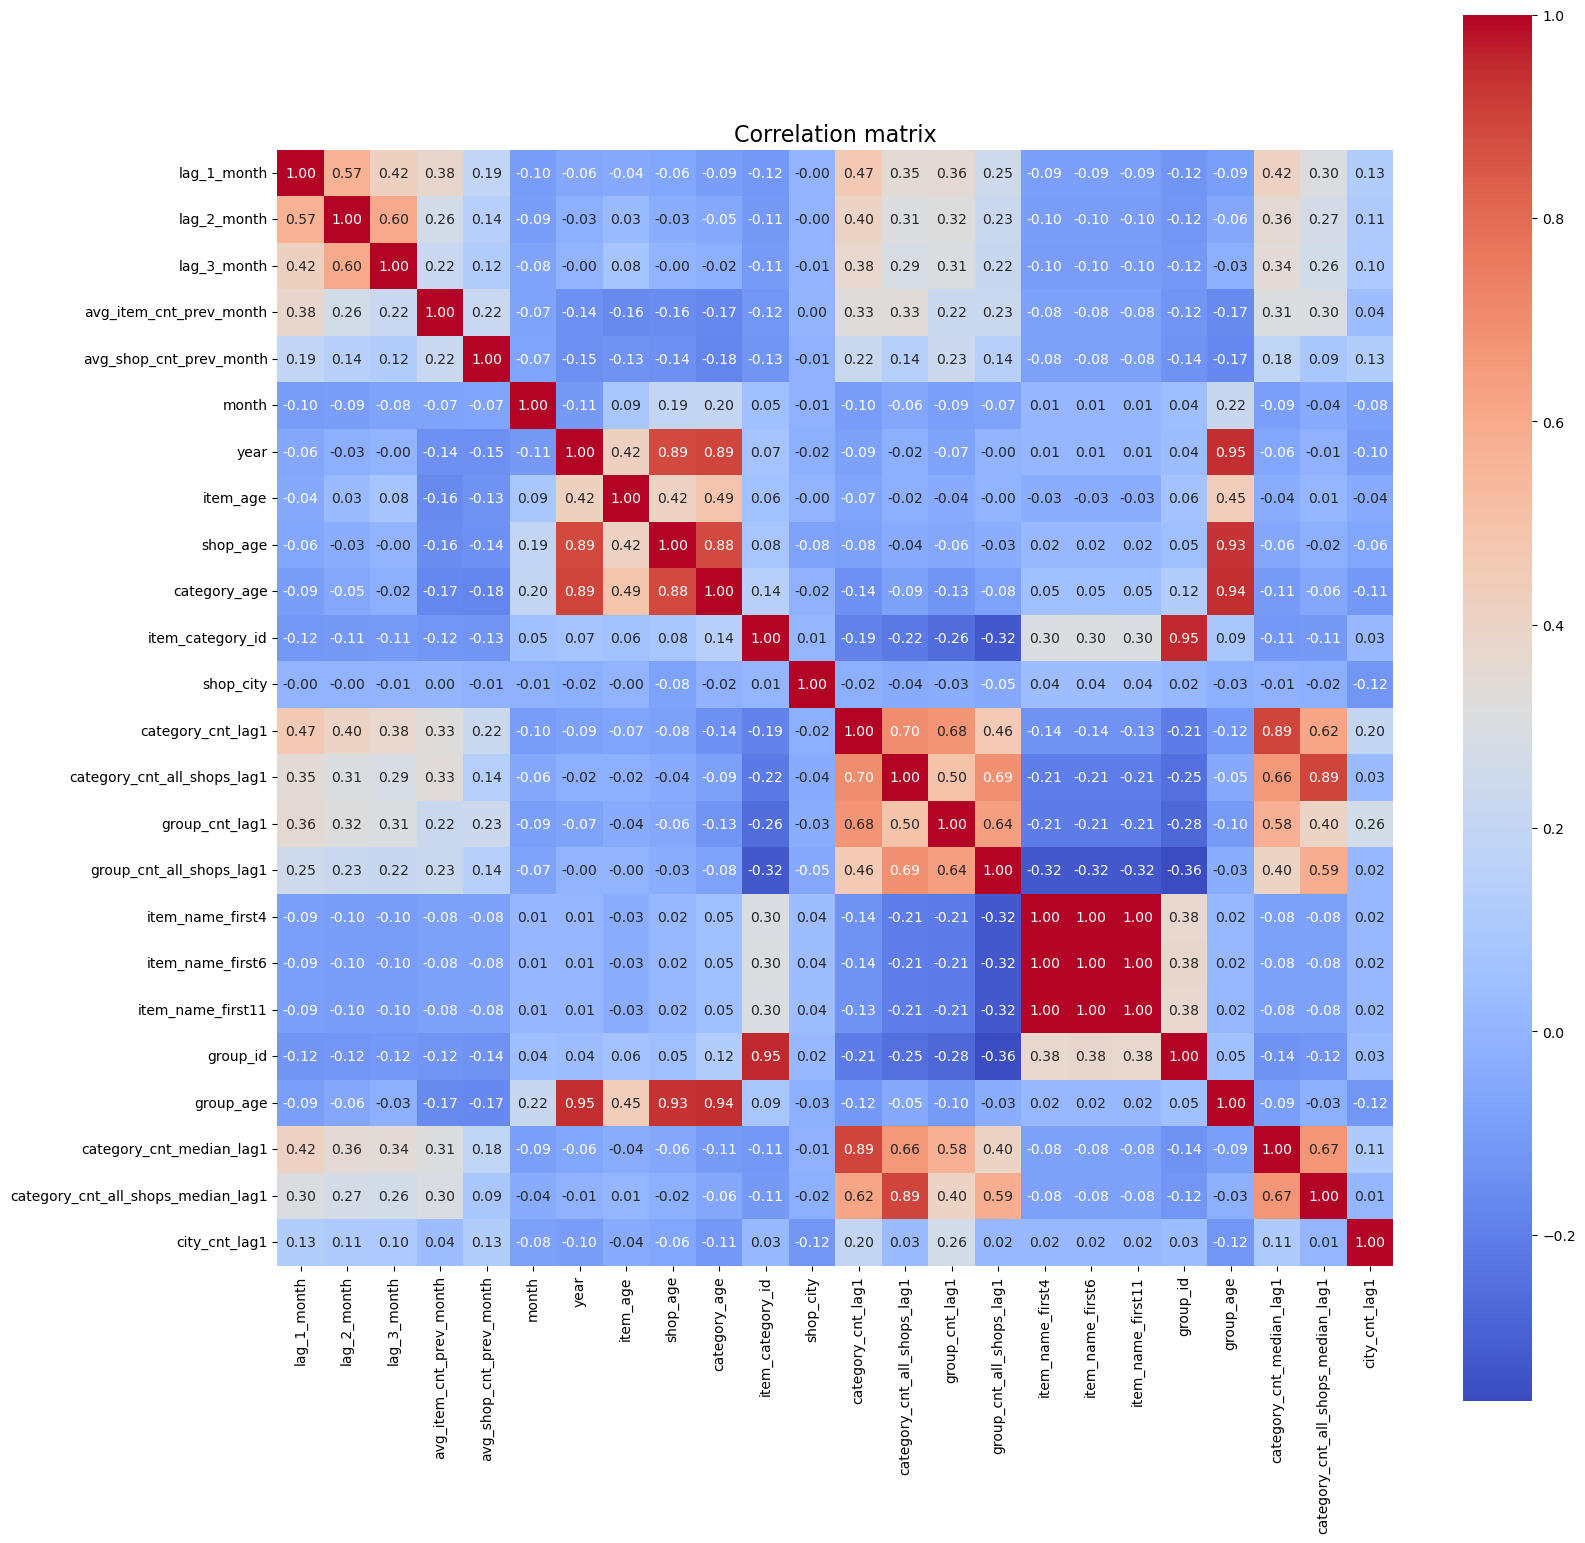

In [12]:
# Display the correlation matrix
plt.figure(figsize=(18, 18))
plt.title("Correlation matrix", fontsize=16)
corr_matrix = x_full.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True);

Some features like item_name_firstx are strongly correlated with each other. item_id and item_category_id also show high correlation. year and age are closely linked. Lag features by category, medium, and all shops are strongly related and may overlap.

## Feature importance

In [15]:
# Get best model
with open("../pipe/models/model_wthout_feat_selection.pkl", "rb") as file:
    model = dill.load(file)

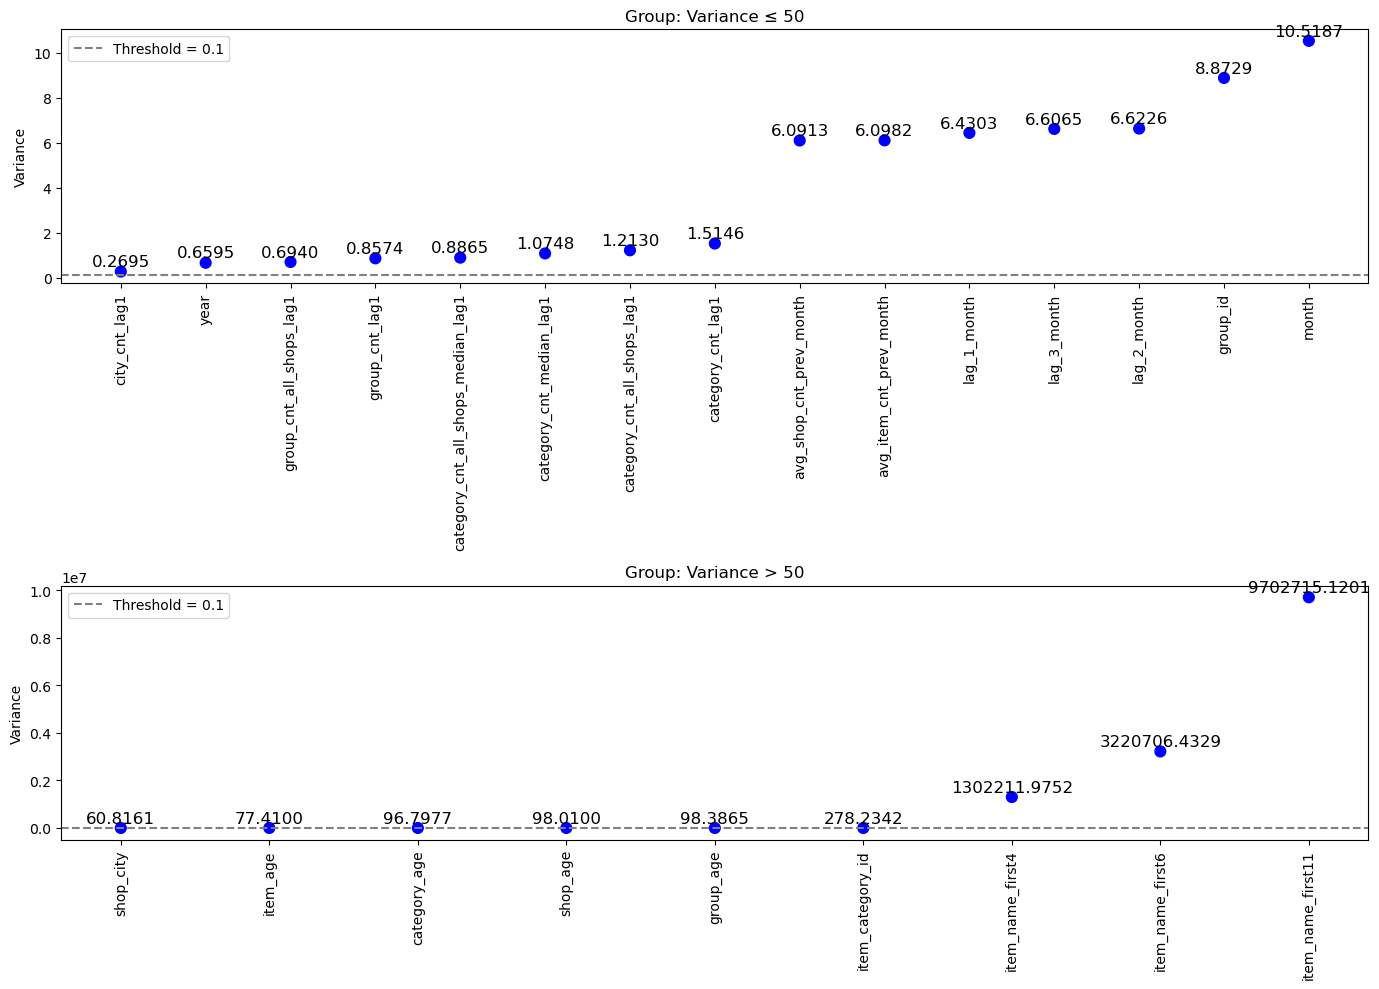

In [16]:
# Analyze feature-wise variance and flag low-variance features
def analyze_feature_variance(x, threshold=0.01):
    variances = x.var(ddof=0)  # Compute variance for each feature
    nunique = x.nunique()      # Count unique values per feature
    summary = pd.DataFrame({
        'feature': variances.index,
        'variance': variances.values,
        'nunique': nunique.values,
        'low_variance': variances.values < threshold  # Flag features below threshold
    }).sort_values(by='variance')
    return summary

# Visualize variance grouped into two categories: low and high dispersion
def plot_feature_variance_by_disp_groups(summary, threshold=0.1, split=50):
    # Split features into two groups based on variance threshold
    group1 = summary[summary['variance'] <= split]
    group2 = summary[summary['variance'] > split]
    groups = [(f'Variance ≤ {split}', group1), (f'Variance > {split}', group2)]

    fig, axes = plt.subplots(nrows=2, figsize=(14, 10), sharex=False)

    for ax, (title, group) in zip(axes, groups):
        group = group.sort_values(by='variance').reset_index(drop=True)
        x_vals = range(len(group))
        # Color-code: red for low-variance, blue otherwise
        colors = ['red' if lv else 'blue' for lv in group['low_variance']]

        # Scatter plot of variances
        ax.scatter(x_vals, group['variance'], c=colors, s=60)
        # Annotate each point with its variance value
        for i, (x, y) in enumerate(zip(x_vals, group['variance'])):
            ax.text(x, y + 0.01 * group['variance'].max(), f"{y:.4f}", ha='center', va='bottom', fontsize=12)

        # Add horizontal threshold line
        ax.axhline(threshold, color='gray', linestyle='--', label=f'Threshold = {threshold}')
        ax.set_title(f'Group: {title}')
        ax.set_ylabel('Variance')
        ax.set_xticks(x_vals)
        ax.set_xticklabels(group['feature'], rotation=90)
        ax.legend()

    plt.tight_layout()
    plt.show()

# Run variance analysis and plot grouped results
summary = analyze_feature_variance(x_full)
plot_feature_variance_by_disp_groups(summary)


The feature city_cnt_lag1 has a variance of 0.26, which is low compared to other features in the dataset. While it is above the threshold of 0.1, it still indicates limited variability across samples. This could suggest that the feature may not contribute significantly to model performance, especially if other features show much higher variance. 

In contrast, features like item_name_first4, item_name_first6, item_name_first11 exhibit significantly higher variance, because of their label encoding and large amount of unique values.

Both features with high and low variance may be insignificant for our model.

In [18]:
# Scale x
x_scaler = StandardScaler()
x_scaler.fit(x_raw)
scaled_x = x_scaler.transform(x_raw)
x = pd.DataFrame(scaled_x, columns=x_raw.columns, index=x_raw.index)

# Scale x_full
xfull_scaler = StandardScaler()
xfull_scaler.fit(x_full)
scaled_x = xfull_scaler.transform(x_full)
x_full = pd.DataFrame(scaled_x, columns=x_full.columns, index=x_full.index)

In [19]:
# Import base rfr model for feature selection
with open("../pipe/models/rfr.pkl", "rb") as file:
    rf = dill.load(file)

In [20]:
x_full.shape

(1363322, 24)

In [21]:
importances = rf.feature_importances_
selector = FeatureSelector()
importance_df = selector.evaluate_feature_importance(x_full, importances)

Importance-based selection: 7 features out of 24
Selected features: ['avg_item_cnt_prev_month', 'lag_1_month', 'group_age', 'item_age', 'category_cnt_lag1', 'lag_3_month', 'group_cnt_lag1']
Rejected features: ['avg_shop_cnt_prev_month', 'item_category_id', 'category_cnt_median_lag1', 'lag_2_month', 'month', 'group_id', 'shop_city', 'category_cnt_all_shops_median_lag1', 'city_cnt_lag1', 'category_age', 'category_cnt_all_shops_lag1', 'shop_age', 'group_cnt_all_shops_lag1', 'item_name_first11', 'year', 'item_name_first6', 'item_name_first4']


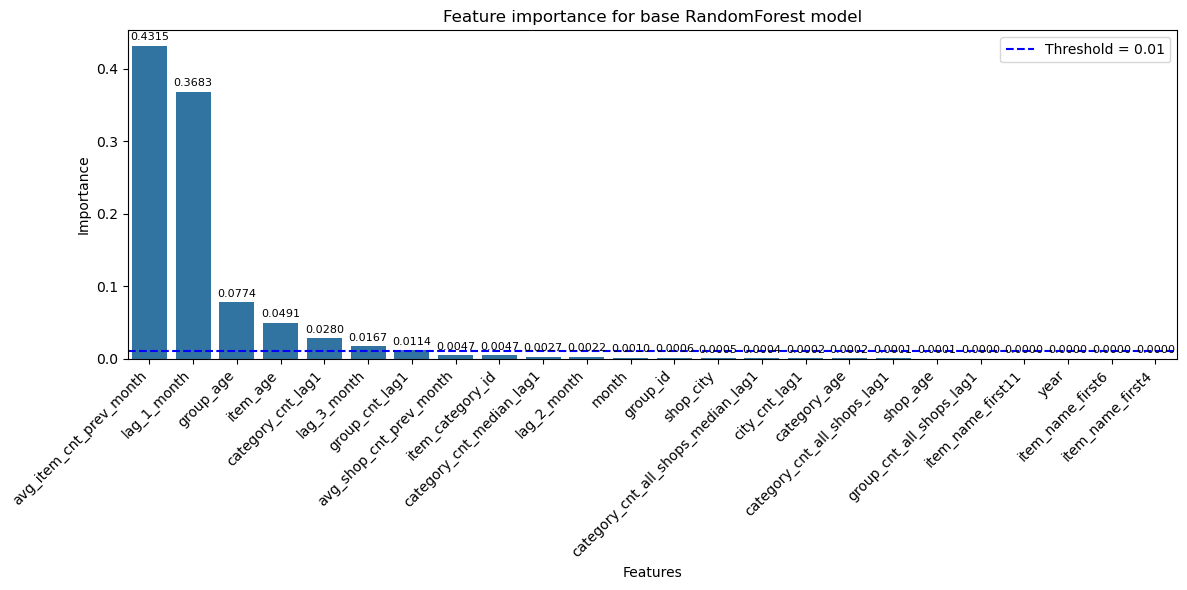

In [22]:
# Visualize feature importance for rf base model
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=importance_df,
    x='feature',
    y='importance',
)

# Add labels 
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,  
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.axhline(0.01, color='blue', linestyle='--', label='Threshold = 0.01')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature importance for base RandomForest model')
plt.legend()
plt.tight_layout()
plt.show()

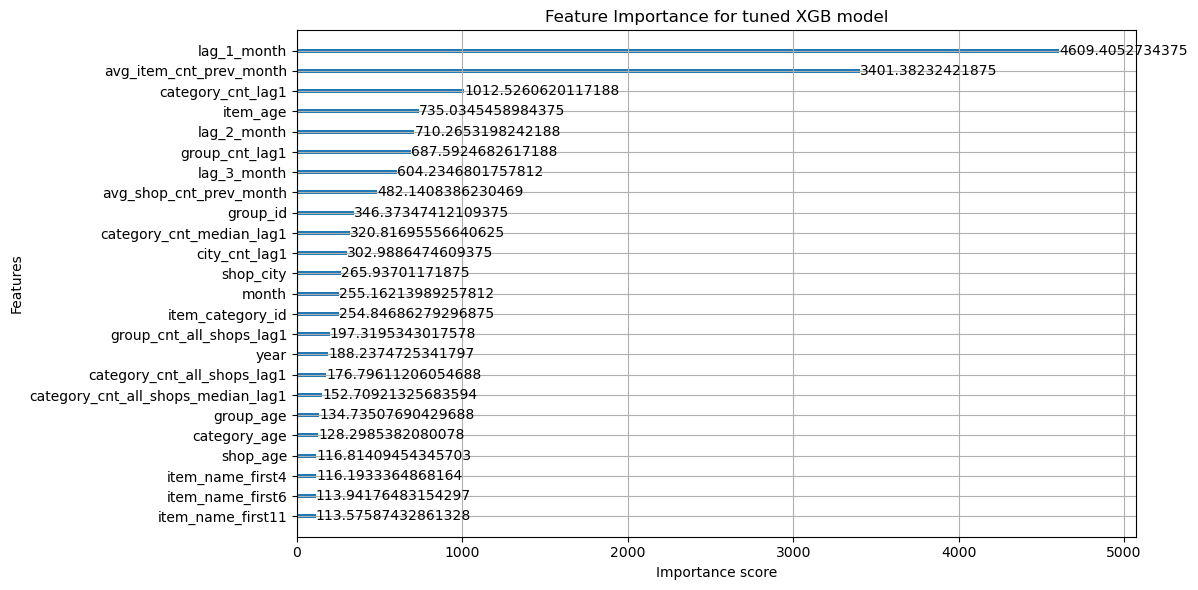

In [23]:
# Feature imortance for xgb
fig, ax = plt.subplots(figsize=(12, 6))
xgb.plot_importance(model, importance_type='gain', ax=ax)
plt.title("Feature Importance for tuned XGB model")
plt.tight_layout()
plt.show()

We need to exclude:
- item_name_fisrtx features wich are highly correlated, have high variance and are unimportant for tuned model.
- group_id, category_cnt_all_shops_lag1, category_cnt_median_lag1 which demonstrate lower importance and high correlation.
- one of the features group_age and category_age should be remained because of high correlation

In [25]:
# Get best model
with open("../pipe/models/sales_model.pkl", "rb") as file:
    model = dill.load(file)["model"]

In [26]:
# Sample 10 000 rows from the full dataset for SHAP analysis
x_sample = x.sample(10000).reset_index(drop=True)

# # Compute SHAP values for the sampled data
# explainer = shap.TreeExplainer(model, approximate=True)
# shap_values = explainer(x_sample)

with open("shap_values.pkl", "rb") as file:
    shap_values = dill.load(file)

In [27]:
# with open("shap_values.pkl", "wb") as file:
#     dill.dump(shap_values,file)

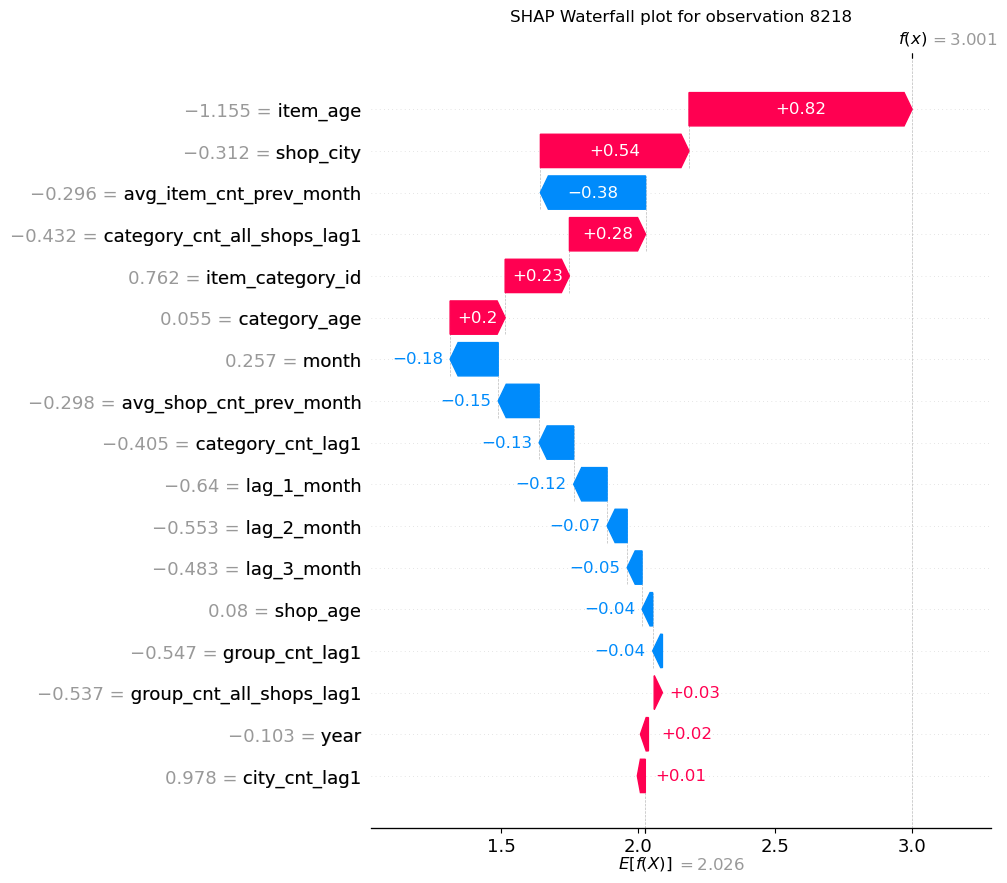

In [28]:
# Get an individual observation
instance_index = random.randint(0, len(x_sample) - 1)
# Visualize its importance

plt.title("SHAP Waterfall plot for observation {}".format(instance_index))
shap.plots.waterfall(shap_values[instance_index], max_display=25)

In [29]:
# # Force plot for an observation
# x_instance = x.iloc[[instance_index]]
# shap.initjs()
# print("Force plot of prediction for one observation")
# shap.force_plot(explainer.expected_value, shap_values[instance_index].values, x_instance)

The most impactful positive features include `category_cnt_all_shops_log1`, `item_age`, and `shop_city`. In contrast, raw features like `avg_item_cnt_prev_month` and `month` had strong negative SHAP values. 

Features `city_cnt_lag1`, `year`, `group_cnt_all_shops_lag1` were unimportant in prediction of the value for individual observation

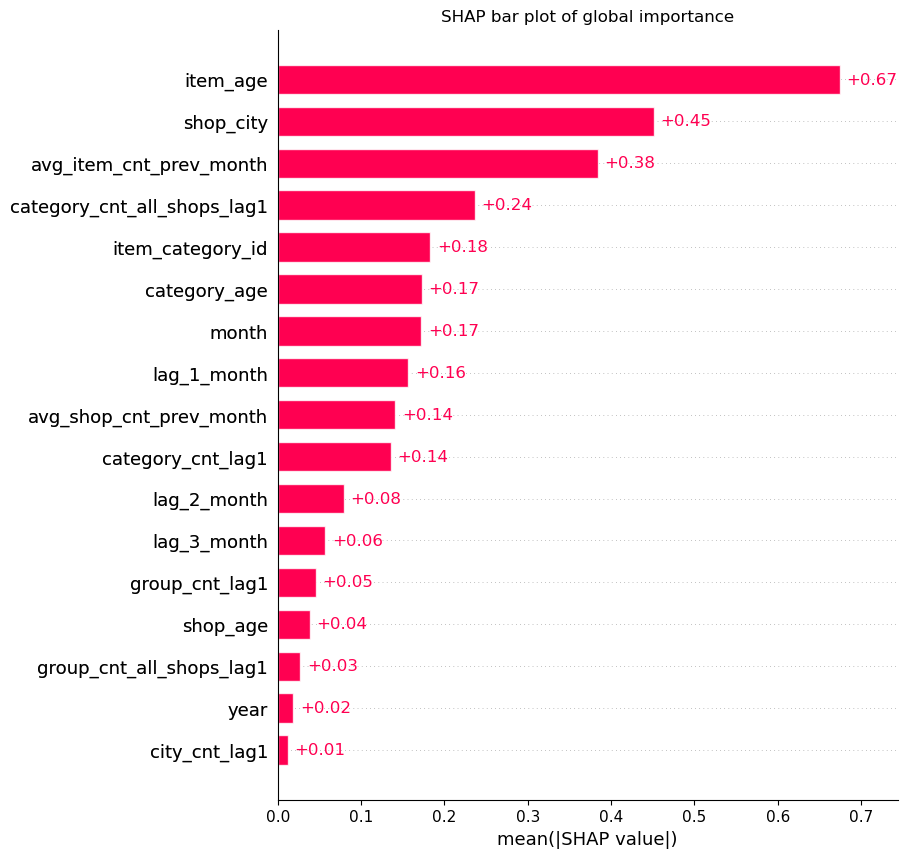

In [31]:
# Show global importance of features
plt.title("SHAP bar plot of global importance")
shap.plots.bar(shap_values, max_display=25)

Less important features in the model include `city_cat_lag_1`, `group_cnt_all_shops_lag1`, and `year`, as they have the lowest mean absolute SHAP values and minimal impact on predictions. As we have seen before, theese features demontrate high correlation.

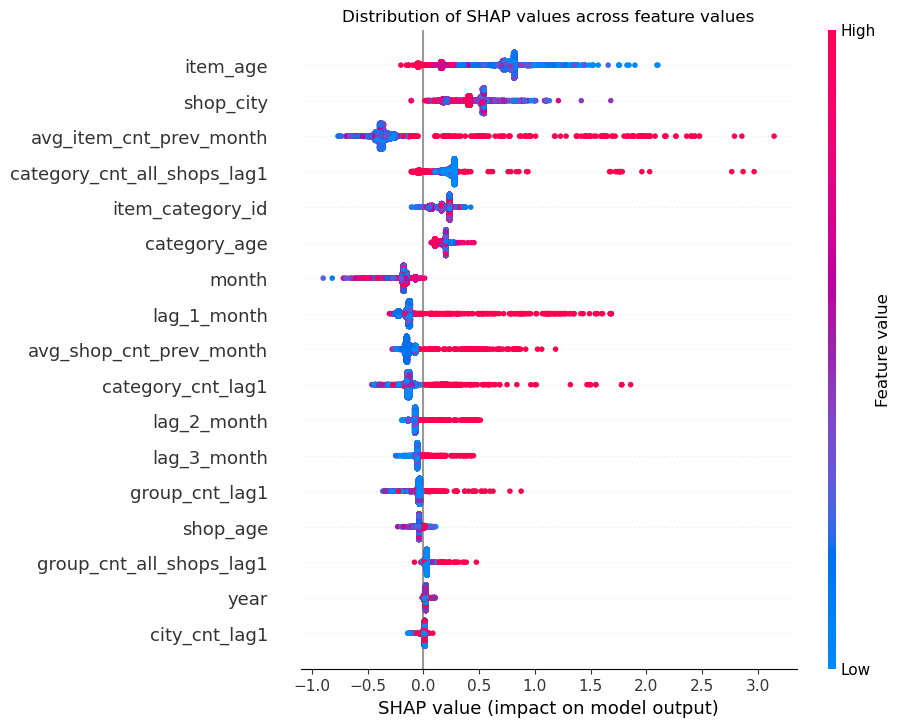

In [33]:
# Show beeswarm plot
plt.title("Distribution of SHAP values across feature values")
shap.plots.beeswarm(shap_values, max_display=25)

SHAP Dependence plot for 'avg_item_cnt_prev_month'


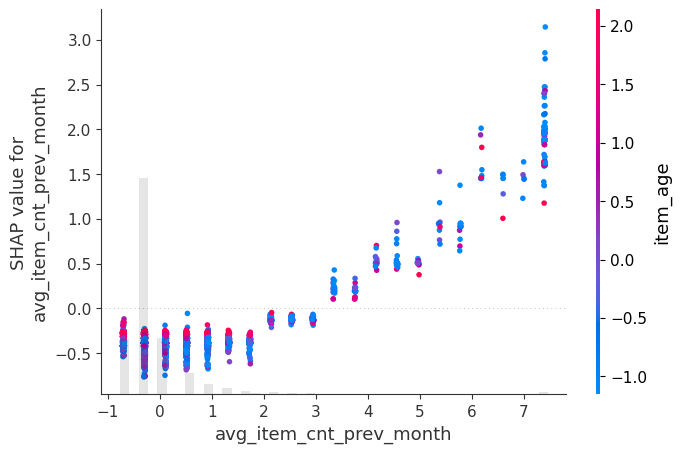

SHAP Dependence plot for 'category_cnt_lag1'


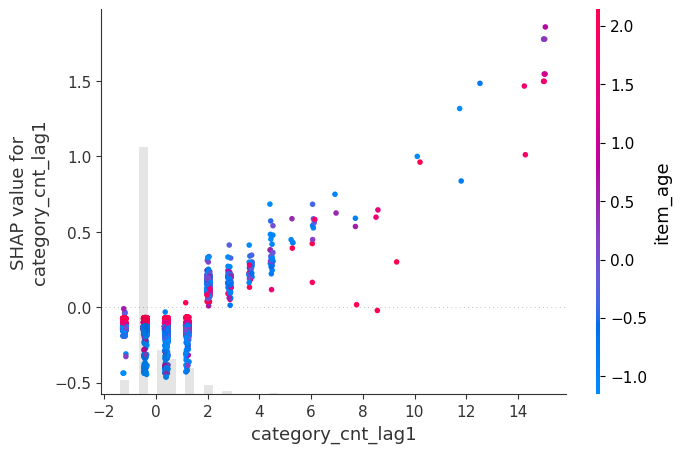

SHAP Dependence plot for 'shop_age'


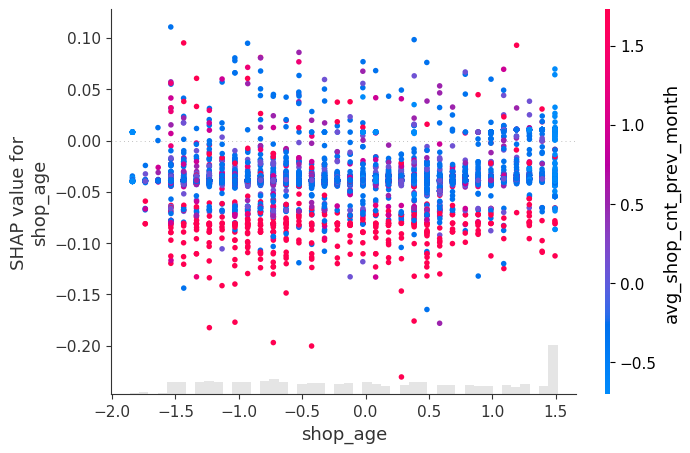

In [34]:
# Chose top-3 features by mean Shap value
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_features = np.array(x.columns)[np.argsort(mean_abs_shap)[-3:]]

# Визуализация
for feature_name in top_features:
    print(f"SHAP Dependence plot for '{feature_name}'")
    shap.plots.scatter(shap_values[:, feature_name], color=shap_values)

- Higher values of `avg_item_cnt_prev_month` lead to higher sales, especially for older items, suggesting stable demand patterns and a strong positive contribution to the model.
- Certain cities strongly influence item age, with older items showing higher SHAP values, suggesting geographic patterns in product turnover.
- Older items with recent sales have the strongest positive impact, showing that long-lived products with fresh demand drive predictions.

In [36]:
x.shape

(1363322, 17)

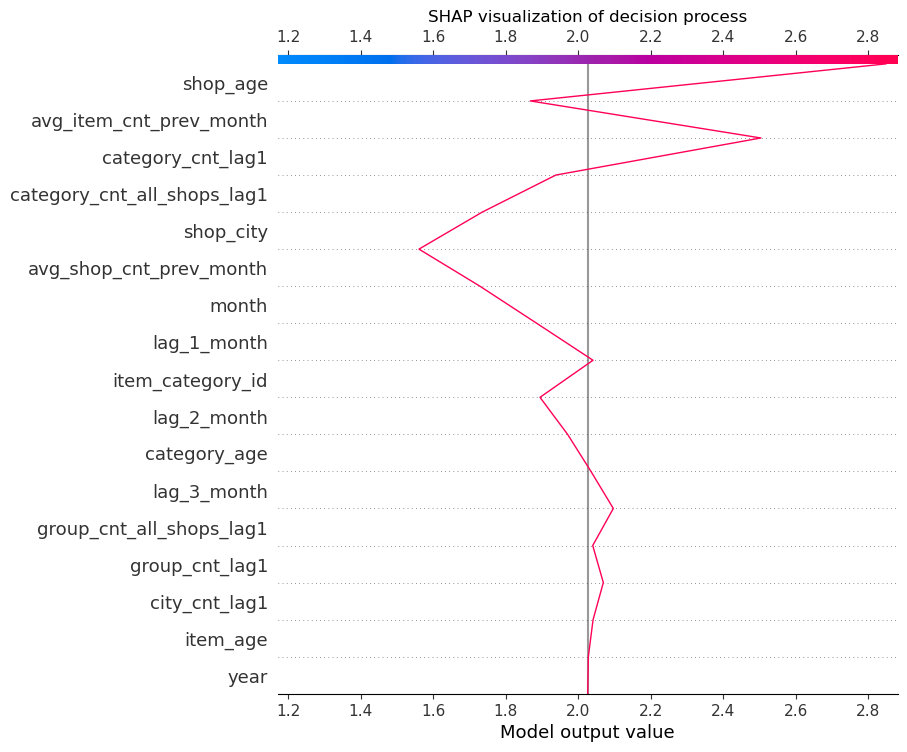

In [37]:
# Show decision plot with title
plt.title("SHAP visualization of decision process")

# Extract SHAP values and base value for one instance
instance_index = 0
shap_array = shap_values.values[instance_index]
base_value = shap_values.base_values[instance_index]
feature_names = x.columns.tolist()  # or x.columns if using full data

# Plot decision path with feature names
shap.plots.decision(
    base_value=base_value,
    shap_values=shap_array,
    feature_names=feature_names
)

## Error analysis

In [39]:
class ModelErrorAnalyzer:
    def __init__(self, error_log: pd.DataFrame):
        self.df = error_log.copy()
        self.df['error_sign'] = self.df['error'].apply(lambda x: 'Over' if x > 0 else 'Under')

    def _finalize_plot(self, *, title='', xlabel='', ylabel='', legend=True, rotate_xticks=False, figsize=(8, 5)):
        plt.gcf().set_size_inches(*figsize)
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if rotate_xticks:
            plt.xticks(rotation=45, ha='right')
        if legend:
            handles, labels = plt.gca().get_legend_handles_labels()
            if handles and labels:
                plt.legend(handles=handles, labels=labels, loc='upper right')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def _styled_scatter(self, *, x, y, hue=None, palette=None, color=None, ax=None):
        sns.scatterplot(
            data=self.df,
            x=x,
            y=y,
            hue=hue,
            palette=palette,
            color=color,
            alpha=0.6,
            ax=ax
        )

    def plot_error_vs_target_magnitude(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

        self._styled_scatter(
            x='target_magnitude', y='error', hue='error_sign',
            palette={'Over': 'crimson', 'Under': 'royalblue'}, ax=axes[0]
        )
        axes[0].set_title('Signed Error vs Target Magnitude')
        axes[0].set_xlabel('Target Magnitude')
        axes[0].set_ylabel('Prediction Error')
        axes[0].grid(True)
        axes[0].legend(title='Error Type', loc='upper right')

        self._styled_scatter(
            x='target_magnitude', y='abs_error', color='darkorange', ax=axes[1]
        )
        axes[1].set_title('Absolute Error vs Target Magnitude')
        axes[1].set_xlabel('Target Magnitude')
        axes[1].set_ylabel('Absolute Error')
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_error_vs_target_dynamic(self):
        self._styled_scatter(
            x='target_dynamic', y='error', hue='error_sign',
            palette={'Over': 'crimson', 'Under': 'royalblue'}
        )
        self._finalize_plot(
            title='Signed Error vs Target Dynamics',
            xlabel='Target Change Rate',
            ylabel='Prediction Error',
            legend=True
        )

    def report_top_errors(self, top_n=10):
        top = self.df.nlargest(top_n, 'abs_error')
        print("Top error samples:")
        print(top[['timestamp', 'y_true', 'y_pred', 'error']])

    def plot_signed_error_distribution(self):
        sns.histplot(self.df['error'], bins=100, kde=True, color='gray')
        plt.axvline(0, color='black', linestyle='--')
        self._finalize_plot(
            title='Signed Prediction Error Distribution',
            xlabel='Prediction Error (y_pred - y_true)',
            ylabel='Frequency',
            legend=True
        )

    def correlate_error_with_features(self, exclude_cols=None):
        exclude = set(exclude_cols or ['timestamp', 'y_true', 'y_pred', 'error', 'abs_error'])
        feature_cols = [c for c in self.df.select_dtypes('number') if c not in exclude]
        correlations = self.df[feature_cols].corrwith(self.df['error'])

        sns.barplot(x=correlations.index, y=correlations.values)
        self._finalize_plot(
            title='Correlation with Prediction Error',
            ylabel='Pearson Correlation',
            rotate_xticks=True,
            figsize=(10, 5)
        )

    def flag_systematic_bias(self, feature='target_magnitude'):
        X = self.df[[feature]].values
        y = self.df['error'].values
        model = LinearRegression().fit(X, y)
        r2 = r2_score(y, model.predict(X))
        print(f"R² = {r2:.3f} → {'Bias detected' if r2 > 0.2 else 'No strong bias'}")


In [40]:
validator = TimeSeriesValidator()
print("Negative RMSE errors by fold")
validator.validate(model, x, pd.Series(y))

Negative RMSE errors by fold


array([-1.81928174, -1.64551966, -1.61181886, -1.28706602])

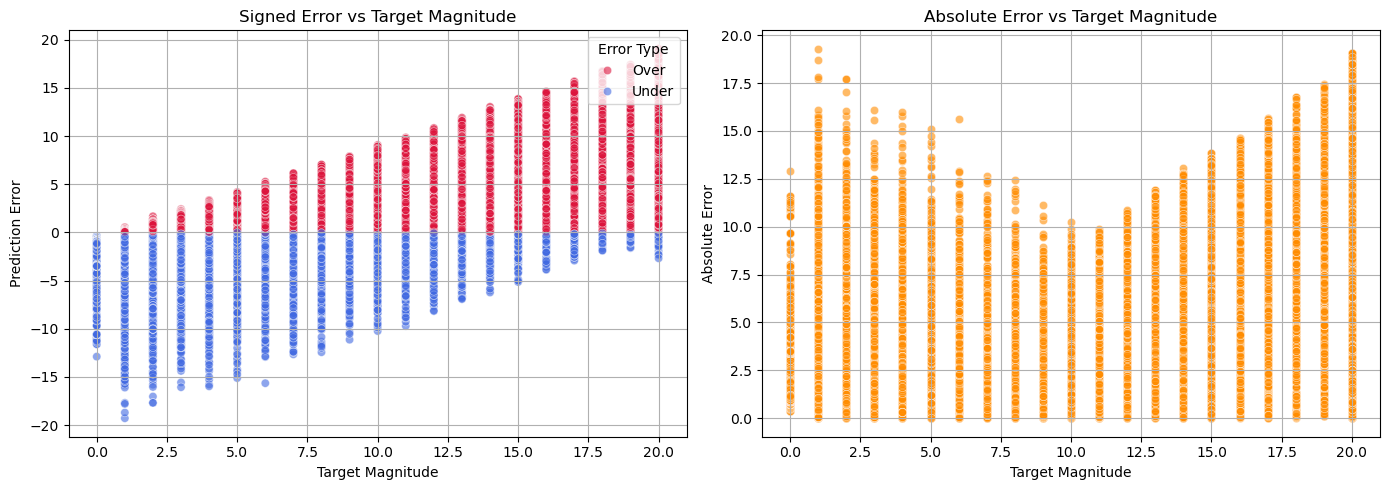

In [41]:
error_analyser = ModelErrorAnalyzer(validator.error_log)
error_analyser.plot_error_vs_target_magnitude()

The model performs most reliably within a mid-range of target values. Errors tend to increase at both low and high values of terget feature. We underpredict values with lower target magnitude.

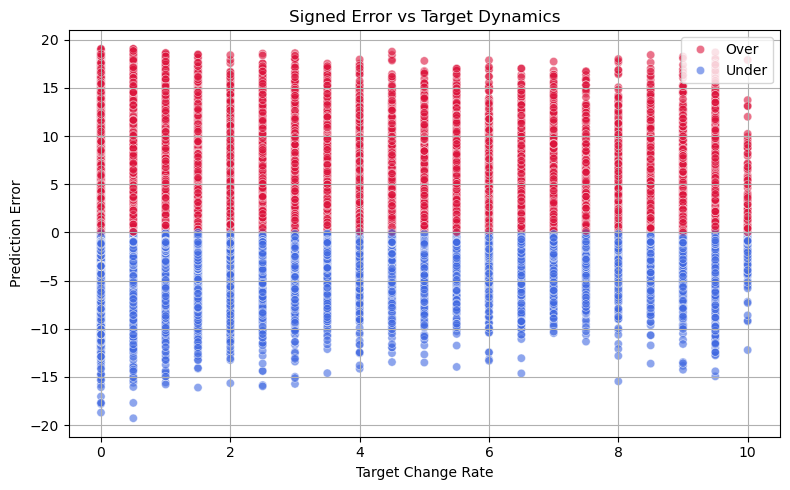

In [43]:
error_analyser.plot_error_vs_target_dynamic()

The scatter plot shows no clear dependency, suggesting that the model's prediction error is not significantly influenced by the rate of change or volatility of the target variable. This indicates that the model maintains consistent performance across varying levels of target dynamics, and does not exhibit systematic bias toward stable or fluctuating patterns.

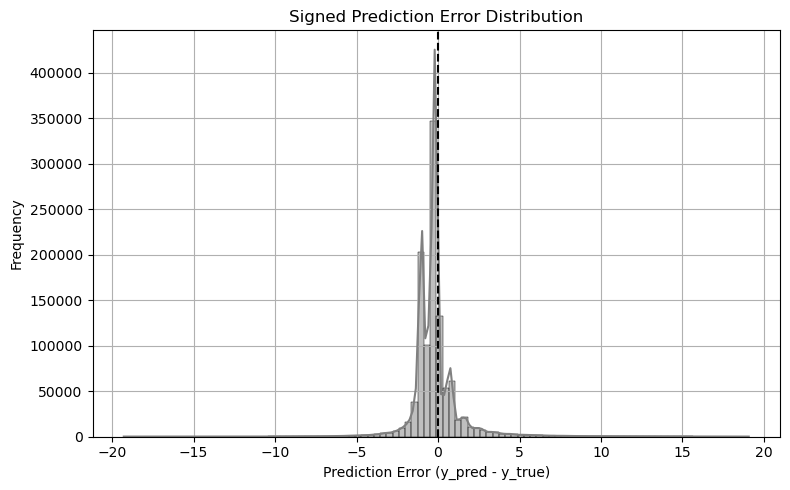

In [45]:
error_analyser.plot_signed_error_distribution()

The model performs reliably, as errors are concentrated near zero and follow a distribution close to normal.

In [47]:
error_analyser.report_top_errors()

Top error samples:
         timestamp  y_true     y_pred      error
435246      707912     1.0  20.284973 -19.284973
1002769    1275435    20.0   0.931923  19.068077
1002870    1275536    20.0   0.931923  19.068077
1001255    1273921    20.0   0.938762  19.061238
1003957    1276623    20.0   0.942570  19.057430
248240      520906    20.0   1.063593  18.936407
358858      631524    20.0   1.122493  18.877507
1014375    1287041    20.0   1.148205  18.851795
419205      691871    20.0   1.149055  18.850945
612188      884854    20.0   1.222084  18.777916


The model shows the highest errors when the target feature reaches a value of 20. We have anomaly with the highest error and y_true=1

### Anomaly analysis

In [50]:
# The anomaly with the highest error
row_index = 435246
target_row = x.iloc[row_index]
pd.DataFrame([target_row])

,lag_1_month,lag_2_month,lag_3_month,avg_item_cnt_prev_month,avg_shop_cnt_prev_month,month,item_age,shop_age,category_age,item_category_id,shop_city,category_cnt_lag1,category_cnt_all_shops_lag1,group_cnt_lag1,group_cnt_all_shops_lag1,city_cnt_lag1,year
435246,-0.246032,-0.164078,-0.094347,-0.295685,-0.297724,-1.901041,0.208548,-0.829303,-0.656335,0.881806,1.611299,-0.404859,-0.432234,-0.547104,-0.537285,0.978123,-0.103471


In [51]:
# Decoded row
x_raw.iloc[row_index]

lag_1_month                       1
lag_2_month                       1
lag_3_month                       1
avg_item_cnt_prev_month           1
avg_shop_cnt_prev_month           1
month                             1
item_age                         12
shop_age                         10
category_age                     12
item_category_id                 57
shop_city                        28
category_cnt_lag1                 1
category_cnt_all_shops_lag1       1
group_cnt_lag1                    1
group_cnt_all_shops_lag1          1
city_cnt_lag1                     2
year                           2014
Name: 435246, dtype: int64

In [52]:
# Compute feature-wise statistics
stats = {'Mean': x.mean(), 'Max': x.max(), 'Min': x.min()}

# Build deviation table for the target row
deviation_table = pd.DataFrame({'Feature Value': target_row})
for name, ref in stats.items():
    deviation_table[f'From {name}'] = target_row - ref
    deviation_table[f'Abs From {name}'] = (target_row - ref).abs()

# Determine which reference value is closest
def closest_stat(row):
    return min(stats, key=lambda k: row[f'Abs From {k}'])

deviation_table['Closest To'] = deviation_table.apply(closest_stat, axis=1)

# Sort by largest absolute deviation from the mean
deviation_table = deviation_table.sort_values(by='Abs From Mean', ascending=False)

# Define color styling for deviations
def color_deviation(val):
    if isinstance(val, str): return 'color: black'
    return 'color: blue' if val < 0 else 'color: red' if val > 0 else ''

# Apply styling
styled = deviation_table[[f'From {k}' for k in stats] + ['Closest To']].style.map(color_deviation)

# Display styled table
styled

,From Mean,From Max,From Min,Closest To
month,-1.901041,-3.391656,0.000000,Min
shop_city,1.611299,-0.128230,3.590448,Max
city_cnt_lag1,0.978123,-1.926418,3.852835,Mean
item_category_id,0.881806,-1.558720,3.417194,Mean
shop_age,-0.829303,-2.323233,1.010101,Mean
category_age,-0.656335,-2.134454,1.219688,Mean
group_cnt_lag1,-0.547104,-20.518718,1.079933,Mean
group_cnt_all_shops_lag1,-0.537285,-22.807463,1.200393,Mean
category_cnt_all_shops_lag1,-0.432234,-17.251414,0.907969,Mean
category_cnt_lag1,-0.404859,-15.438233,0.812539,Mean


In [53]:
# Define the city
le_city_df.iloc[[28]]

,Encoded Label,Original Value
28,28,якутск


In [54]:
# Show value count for city "якутск"
x["shop_city"].value_counts().iloc[:2]

shop_city
-0.312156    363151
 1.611299    102095
Name: count, dtype: int64

Town Yakutsk is the second on popularity. The anomaly has this city.

In [56]:
# Define the category
cats_df.iloc[[57]]

,item_category_name,item_category_id
57,Музыка - MP3,57


In [57]:
x[x["item_category_id"]==0.881806043037064].shape

(21616, 17)

The anomaly belongs to the category Music wich is quite popular

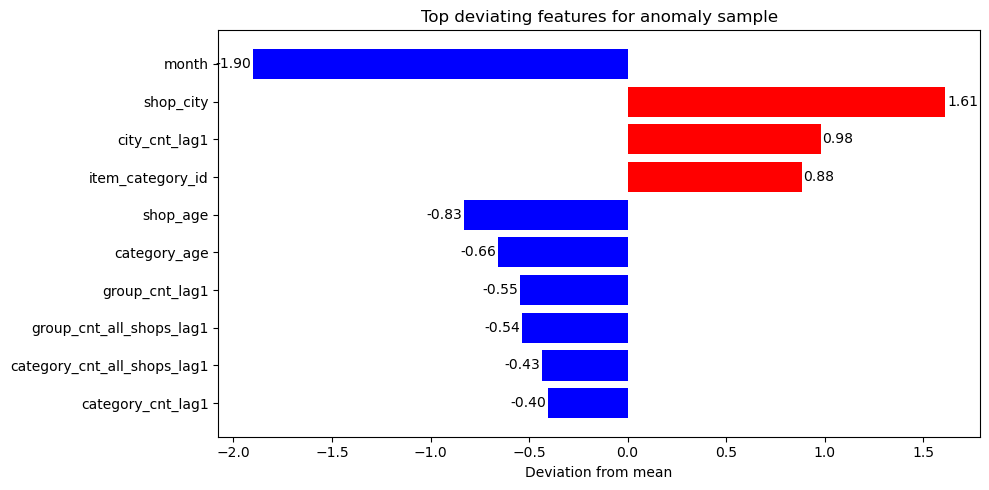

In [59]:
# Select top 10 features with the largest deviation from the mean
top_deviations = deviation_table.head(10)

# Extract deviation values and corresponding feature labels (reversed for plotting)
values = top_deviations['From Mean'][::-1]
labels = top_deviations.index[::-1]

# Assign colors: red for positive deviations, blue for negative
colors = ['red' if val > 0 else 'blue' for val in values]

# Create horizontal bar chart
plt.figure(figsize=(10, 5))
bars = plt.barh(labels, values, color=colors)

# Add value labels to each bar with medium font weight
for bar, val in zip(bars, values):
    plt.text(
        val + (0.01 if val > 0 else -0.01),  # slight offset from bar edge
        bar.get_y() + bar.get_height() / 2,  # vertical centering
        f'{val:.2f}',                        # formatted value
        va='center',
        ha='left' if val > 0 else 'right',
        fontsize=10,
        fontweight='medium'
    )

# Add axis label and title
plt.xlabel('Deviation from mean')
plt.title('Top deviating features for anomaly sample')
plt.tight_layout()
plt.show()


The observation appears largely typical across most features, with 14 out of 17 values closest to their respective means. This suggests the sample does not exhibit extreme behavior in most dimensions. However, two features stand out: `month`, which aligns with the minimum (likely indicating the start of a time period), and `shop_city`, which is closest to the maximum ().

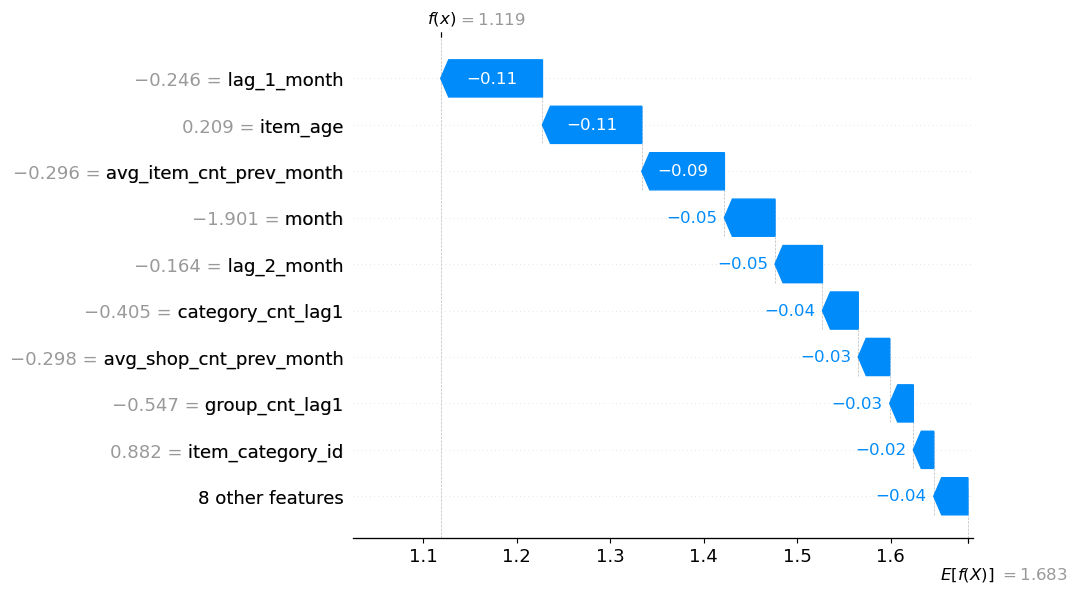

In [61]:
# Select the index of the anomalous sample
row_index = 435246
target_row = x.iloc[row_index]

# Initialize SHAP explainer using the model and full dataset
explainer = shap.Explainer(model, x)

# Generate SHAP values for the selected sample
shap_single = explainer(x.iloc[[row_index]])

# Visualize feature contributions using a waterfall plot
shap.plots.waterfall(shap_single[0])

# Create a DataFrame with SHAP values and their absolute magnitudes
shap_table = pd.DataFrame({
    'Feature': x.columns,
    'SHAP Value': shap_single.values[0],
    'Abs SHAP': np.abs(shap_single.values[0])
}).set_index('Feature')


This observation had the biggest error in the dataset (−20), and the top features—like **lag_1_month**, **item_age**, and **avg_item_cnt_prev_month**—all pushed the prediction down. That’s likely why the model underestimated the actual value so much. Less important features, like **group_cnt_lag1**, didn’t help correct the mistake.

### Error correlation

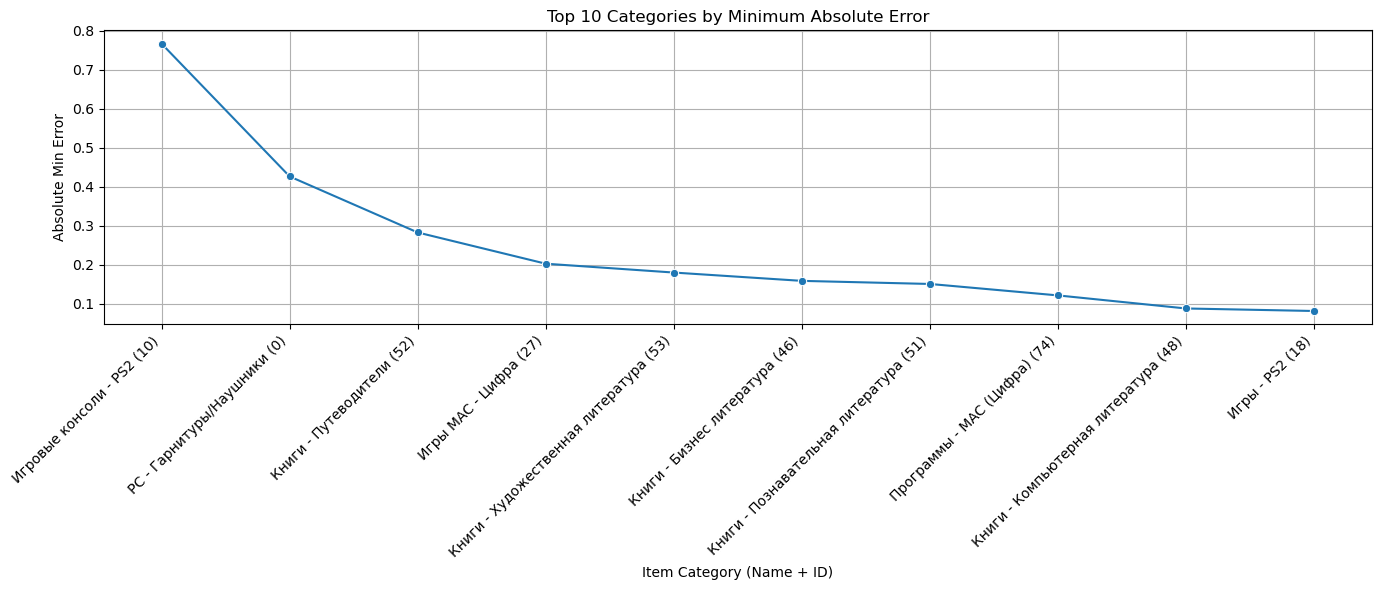

Top 10 categories with highest error and their frequency:


,item_category_name,item_category_id,count,percent
0,Программы - MAC (Цифра),74,16,0.0
1,Книги - Бизнес литература,46,10,0.0
2,Игры MAC - Цифра,27,6,0.0
3,Игры - PS2,18,4,0.0
4,Книги - Путеводители,52,3,0.0
5,Книги - Компьютерная литература,48,3,0.0
6,Книги - Художественная литература,53,3,0.0
7,Игровые консоли - PS2,10,1,0.0
8,PC - Гарнитуры/Наушники,0,1,0.0
9,Книги - Познавательная литература,51,1,0.0


In [64]:
# Merge error log with decoded item_category_id from x_raw
merged = validator.error_log.join(x_raw[['item_category_id']], how='left')

# Group by item_category_id and calculate minimum absolute error
error_by_category = merged.groupby('item_category_id')['abs_error'].min().reset_index()

# Merge with category names from cats_df
error_by_category = error_by_category.merge(cats_df, on='item_category_id', how='left')

# Create label: "Category Name (ID)"
error_by_category['category_label'] = error_by_category['item_category_name'] + ' (' + error_by_category['item_category_id'].astype(str) + ')'

# Sort by error and select top 10
top10 = error_by_category.sort_values(by='abs_error', ascending=False).head(10)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=top10, x='category_label', y='abs_error', marker='o')

plt.title('Top 10 Categories by Minimum Absolute Error')
plt.xlabel('Item Category (Name + ID)')
plt.ylabel('Absolute Min Error')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Count total records and records per top category
total_records = len(merged)
top_counts = merged[merged['item_category_id'].isin(top10['item_category_id'])]['item_category_id'].value_counts().reset_index()
top_counts.columns = ['item_category_id', 'count']

# Merge with category names
top_counts = top_counts.merge(cats_df, on='item_category_id', how='left')
top_counts['percent'] = (top_counts['count'] / total_records * 100).round(2)

# Display summary table
summary = top_counts[['item_category_name', 'item_category_id', 'count', 'percent']]
print("Top 10 categories with highest error and their frequency:")
summary.sort_values(by='count', ascending=False)

For items from rare categories the minimum error is rather high.

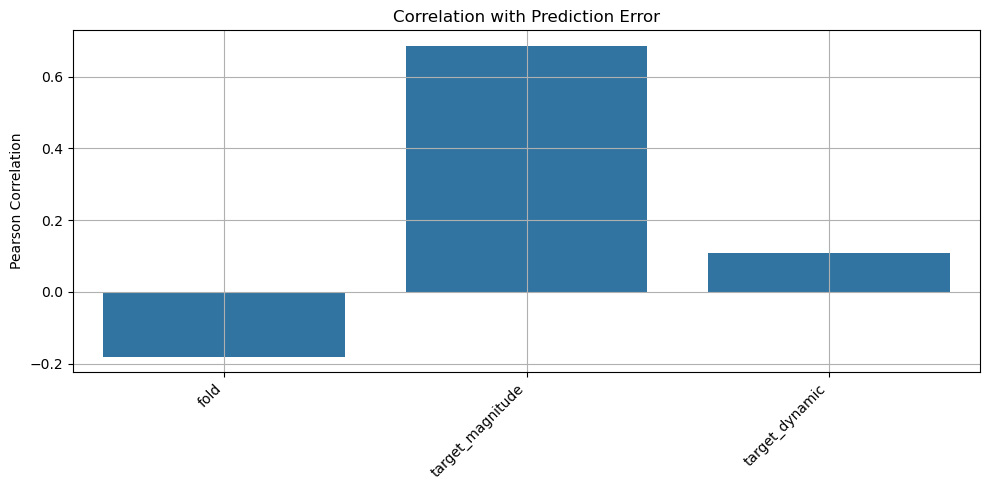

In [66]:
error_analyser.correlate_error_with_features()

In [67]:
error_analyser.flag_systematic_bias()

R² = 0.470 → Bias detected


Error is correlated with target magnitude the most. It is higher for small and high values of target feature. Correlation of error and number of fold is negative, because during feature engineering, we assigned values for future folds based on past ones, since we had more information about historical sales. 

## Conclusion

- The feature analysis revealed that several variables such as `item_name_firstx`, `item_id`, `item_category_id`, and lag-based features—exhibit strong intercorrelation, which may lead to redundancy and reduced model interpretability. 
- Features with both low and high variance, including `city_cnt_lag1` and label-encoded `item_name_firstx`, were found to be either weakly informative or overly noisy, suggesting their exclusion could improve model performance. 
- SHAP values highlighted that `category_cnt_all_shops_log1`, `item_age`, and `shop_city` were the most positively impactful, while features like `avg_item_cnt_prev_month` and `month` consistently contributed negative influence. Several features, including `year`, `group_cnt_all_shops_lag1`, and `city_cat_lag_1`, showed minimal predictive power and high correlation, supporting their removal.
- Model diagnostics showed reliable performance across most target ranges, with errors concentrated near zero and no strong bias toward volatility. However, the largest prediction error (−20) occurred on a sample with `y_true = 1`, belonging to the popular Music category and the city of Yakutsk—both typically associated with higher sales. Despite the sample appearing typical across most features, the model underestimated its value due to influential features like `lag_1_month`, `item_age`, and `avg_item_cnt_prev_month` pushing the prediction downward. A plausible explanation is that the combination of a low `month` value (likely indicating the start of the time period) created a rare context not well captured by the training data, especially for a popular item in a high-demand region. 
- We should clean up our feature set by removing those that are either too similar to each other or don’t help the model much—like `item_name_firstx`, `year`, and `group_cnt_all_shops_lag1`. This will make the model faster and more accurate. We also need to balance the training data better, especially for rare categories in popular cities, so the model doesn’t miss important patterns. Adding smart combinations of features and improving how we handle time-based data will also help boost prediction quality.